In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", google_api_key=api_key, temperature=0.7)

c:\FAHEEM\My_Programs\RAG_Beginners\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Google api key is set


In [ ]:
from typing import TypedDict, List, Annotated
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from langgraph.graph.message import BaseMessage,add_messages

class llm_schema(BaseModel):
    question: str
    path: str = Field("path for the documents")

class graph_schema(TypedDict):
    query: Annotated[List[BaseMessage], add_messages]
    question: str
    documents: List[Document]
    result: str
    path: str

llm_with_schema = llm.with_structured_output(llm_schema)

In [ ]:
from langchain_core.tools import tool

@tool
def retriever_embedding_tool(question: str, path: str):
    """
    Retrieve relevant information from a specific local document.

    Use this tool when the user asks a question about a PDF, DOCX,
    TXT, Markdown file, or other provided document.

    Args:
        question: The exact question to answer using the document.
        path: The complete filesystem path to the document.
    """
    retrieve.file_loader(path)
    retrieve.text_splitting()
    retrieve.model_calling()

    result = retrieve.vector_embedding(question)

    return result


def memory_embedding_tool():
    """
    Tool used to retrieve information from stored information using memory vector embedding from local memory
    """

In [14]:
tools = [retriever_embedding_tool, memory_embedding_tool]

llm_with_tool = llm.bind_tools(tools)
result = llm_with_tool.invoke("What is INVOLVE an AI powered on demand local service platform? examine a pdf named 29_Paper.pdf inside pdf folder of docs that is inside of C drive then Faheem then My_Programs Rag_Beginners")
result

c:\FAHEEM\My_Programs\RAG_Beginners\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


AIMessage(content=[], additional_kwargs={'function_call': {'name': 'retriever_embedding_tool', 'arguments': '{"query": "INVOLVE AI powered on demand local service platform 29_Paper.pdf"}'}, '__gemini_function_call_thought_signatures__': {'vOL0Ha7l': 'EtEECs4EARFNMg8rSMgyJlA1fh7XpVtOQKDrGzYsWLvUAF2gyPfcLevOKkwTCovMa84CZlG6SgubcePybq79YiehPe8lJn3KgC9fc7bZ2VUtUcq/Hg2IRMa+s6m7KjopgKfxjCPotI/lcaD7h70+DloVhRrAt0a5SslGl9VpHvCUbJwnoP37QrYOhAWGkwy61KpuGZi7H6ddSUFJnZ07kfS4eToVjdN71MRt+n2C7RWZyfbz7xA4pVmYYoqv1aJmoeLqsezkYJWPVLf4qgIt0J/P8ZJOnxYIKO/JBOuQpfrKlhCf1ZwCz4n1CE/1OGmfROuABBZdfrd5VL6msqo/1hj6OXEWMsKtJl8tQhZIJSK/ex/q3ztu3QlTIuLc4Oyys1bAeGgpBf3ExwXlfOHfHNzGJtVSCoD0rWIDVnjBnxni2sl+ng0ION0CeuB//ERXf5mfPMDiBzvfrklp9JDzBBGa9EmUsnIPc0K/FmqMheVovVuOLN4O80+NiD0k7ankiltahuDpESh1Gh7STzXVfcm15Ge+pHn4xUtelbs7HoIAqV8Lm1zDngJKwZmUU58gQp+VGIVNoRJF3gZ6wRWXdc6lDGDZeK2k6pGGDSr1OTbPDPxAzG+jvv8hyIUmcEcn+YM/u716qtUbwk49AeBBQ+cKyV76QA1RsSDMDNB4tkybxhtnLIpJNucuT8Hdm8+5ToE4CqxrVRCTnKYNMDgHRQ5tLontVUh7hyIPZ63i7ENc+

In [ ]:
from RagIntegration import RagRetriever
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import ToolMessage
retrieve = RagRetriever()

def retriever_node(state: graph_schema) -> graph_schema:
    query = state['query']
    response_schema = llm_with_schema.invoke(query)
    response_tool = llm_with_tool.invoke(query)

    question = response_schema.question
    path = response_schema.path
    state['query'] = response_tool

    return {
        "question": question,
        "path": path,
    }

def tool_node(state:graph_schema) -> graph_schema:
    query = state['query']
    tool_name = {tool.name: tool for tool in tools}

    tool_result = []
    
    for tool_call in query[-1].tool_calls:
        tool = tool_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))

    return {
        "result": tool_result
    }

def generator_node(state: graph_schema) -> graph_schema:
    question = state['question']
    document = state['documents']

    context = '\n\n'.join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
            You are a helpful assistant.
            Use only the information provided in the context and answer the question.
            If answer is not present in the context just say exactly.
            'I don't know'
            Context: {context}
        """),
        ("user", """Question: {question}""")
    ])

    chain = prompt | llm

    result = chain.invoke({"context": context, "question": question})

    return {
        "result": result.content
    }

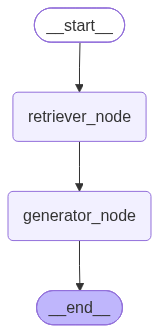

In [12]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("generator_node", generator_node)

graph.add_edge(START, "retriever_node")
graph.add_edge("retriever_node", "generator_node")
graph.add_edge("generator_node", END)

knowledge_assistant = graph.compile()
knowledge_assistant

In [13]:
response = knowledge_assistant({
    "query": "What is INVOLVE an AI powered on demand local service platform? examine a pdf named 29_Paper.pdf inside pdf folder of docs that is inside of C drive then Faheem then My_Programs Rag_Beginners",
    "question": "",
    "answer": "",
    "path": "",
    "document": []
})
response
print(f"AI Reply: {response["result"][0]["text"]}")

TypeError: 'CompiledStateGraph' object is not callable

In [ ]:
from memory import LocalMemory
from datetime import datetime
memory = LocalMemory()

memory.save_message(response['question'], response['result'][0]['text'], datetime.now().isoformat())